In [1]:
!pip install roboflow pycocotools kornia
# No special package needed — FracTAL ResUNet is implemented from scratch in PyTorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 122.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 98.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
import os, random, json

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from PIL import Image
from tqdm import tqdm
from pycocotools.coco import COCO

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import kornia.filters as KF

In [3]:
import os
from google.colab import userdata

os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

In [4]:
!nvidia-smi

Tue Apr 14 05:32:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   41C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
import os
HOME = os.getcwd()
print(HOME)

from roboflow import Roboflow

/content


In [6]:
rf = Roboflow(api_key="Wp24o55YexUp4lOqknub")
project = rf.workspace("segmentation-iugrk").project("crop-field-bopay")
version = project.version(6)
dataset = version.download("coco-segmentation")
print("Dataset location:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Crop-Field-6 in coco-segmentation:: 100%|██████████| 399/399 [00:00<00:00, 5493.51it/s]

Dataset location: /content/Crop-Field-6


In [7]:
import os
import json

base_dir = dataset.location  # your dataset root

for split in ['train', 'valid', 'test']:
    ann_file = os.path.join(base_dir, split, '_annotations.coco.json')

    if not os.path.exists(ann_file):
        continue

    print(f"\nFixing {split}...")

    with open(ann_file) as f:
        data = json.load(f)

    # -----------------------------
    # 1. Force SINGLE category
    # -----------------------------
    data['categories'] = [{
        "id": 1,
        "name": "field",
        "supercategory": "field"
    }]

    # -----------------------------
    # 2. Fix ALL annotations
    # -----------------------------
    for ann in data['annotations']:
        ann['category_id'] = 1

    # -----------------------------
    # 3. Save
    # -----------------------------
    with open(ann_file, "w") as f:
        json.dump(data, f)

    print(f"  ✓ {split} fixed")

print("\n✅ Dataset fully cleaned!")


Fixing train...
  ✓ train fixed

Fixing valid...
  ✓ valid fixed

Fixing test...
  ✓ test fixed

✅ Dataset fully cleaned!


In [8]:
# Roboflow coco-segmentation layout:
#   <dataset.location>/
#     train/  _annotations.coco.json  *.jpg
#     valid/  _annotations.coco.json  *.jpg
#     test/   _annotations.coco.json  *.jpg

for split in ['train', 'valid', 'test']:
    split_dir = os.path.join(dataset.location, split)
    ann_file  = os.path.join(split_dir, '_annotations.coco.json')
    if os.path.exists(ann_file):
        with open(ann_file) as f:
            d = json.load(f)
        print(f"[{split}] images: {len(d['images'])}  "
              f"annotations: {len(d['annotations'])}  "
              f"categories: {[c['name'] for c in d['categories']]}")

[train] images: 354  annotations: 5935  categories: ['field']
[valid] images: 27  annotations: 178  categories: ['field']
[test] images: 13  annotations: 113  categories: ['field']


In [15]:
from scipy.ndimage import distance_transform_edt

class CocoSegDataset(Dataset):
    """
    Roboflow coco-segmentation reader.
    Returns (image, seg_mask, boundary_mask, dist_map) for FracTAL multitask training.
      seg_mask      — (H,W) long, class per pixel
      boundary_mask — (H,W) float, 1 at field boundaries
      dist_map      — (H,W) float, normalised distance to nearest boundary
    """
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, split_dir, img_size=512, augment=False):
        ann_file = os.path.join(split_dir, '_annotations.coco.json')
        self.coco      = COCO(ann_file)
        self.img_ids   = list(self.coco.imgs.keys())
        self.split_dir = split_dir
        self.img_size  = img_size
        self.augment   = augment

        cats = self.coco.loadCats(self.coco.getCatIds())
        self.cat2cls     = {c['id']: i+1 for i,c in enumerate(sorted(cats, key=lambda x: x['id']))}
        self.num_classes = len(cats) + 1
        print(f'  {len(self.img_ids)} images | classes: {[c["name"] for c in cats]}')

    def __len__(self): return len(self.img_ids)

    def _build_mask(self, img_id, h, w):
        sem = np.zeros((h,w), dtype=np.uint8)
        for ann in self.coco.loadAnns(self.coco.getAnnIds(imgIds=img_id)):
            rle = self.coco.annToMask(ann)
            sem[rle==1] = self.cat2cls[ann['category_id']]
        return sem

    @staticmethod
    def _make_boundary(mask_np, dilation=4):
        """
        Binary boundary map via erosion difference.

        dilation=4 produces a ~8px wide boundary strip (vs 4px at dilation=2).
        Wider boundaries give the model more positive pixels to learn from and
        make the boundary head signal stronger after Gaussian tile blending.
        The wider strip is also more forgiving of small annotation misalignments.
        """
        import cv2
        field = (mask_np > 0).astype(np.uint8)
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        eroded = cv2.erode(field, k, iterations=dilation)
        boundary = (field - eroded).astype(np.float32)

        # Also mark instance boundaries: pixels where adjacent field instances differ
        # This catches inter-field boundaries that erosion alone misses when two
        # fields share an edge with no gap in the annotation
        instance_bound = np.zeros_like(boundary)
        sem = mask_np.astype(np.int32)
        h_diff = (sem[:-1, :] != sem[1:,  :]).astype(np.float32)
        v_diff = (sem[:, :-1] != sem[:,  1:]).astype(np.float32)
        instance_bound[:-1, :] = np.maximum(instance_bound[:-1, :], h_diff)
        instance_bound[1:,  :] = np.maximum(instance_bound[1:,  :], h_diff)
        instance_bound[:, :-1] = np.maximum(instance_bound[:, :-1], v_diff)
        instance_bound[:,  1:] = np.maximum(instance_bound[:,  1:], v_diff)
        # Dilate instance boundaries to match erosion width
        k2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        instance_bound = cv2.dilate(instance_bound.astype(np.uint8), k2,
                                    iterations=dilation).astype(np.float32)

        return np.clip(boundary + instance_bound, 0.0, 1.0)

    @staticmethod
    def _make_distance(boundary_np):
        """
        Normalised distance from each pixel to nearest boundary, clipped to
        a maximum of 64px before normalising.

        Clipping prevents large fields from having very high distance values
        that dominate the MSE loss and overshadow small-field interior pixels.
        The model learns a plateau-shaped distance map rather than a tent,
        which is more robust for fields of varying size.
        """
        from scipy.ndimage import distance_transform_edt
        non_boundary = (boundary_np == 0).astype(np.uint8)
        dist = distance_transform_edt(non_boundary).astype(np.float32)
        dist = np.clip(dist, 0.0, 64.0)   # cap at 64px
        if dist.max() > 0:
            dist = dist / dist.max()
        return dist

    def __getitem__(self, idx):
        img_id  = self.img_ids[idx]
        info    = self.coco.imgs[img_id]
        img     = Image.open(os.path.join(self.split_dir, info['file_name'])).convert('RGB')
        mask_np = self._build_mask(img_id, info['height'], info['width'])

        # Build auxiliary targets from mask (before resizing to preserve precision)
        boundary_np = self._make_boundary(mask_np)
        dist_np     = self._make_distance(boundary_np)

        mask     = Image.fromarray(mask_np)
        boundary = Image.fromarray((boundary_np * 255).astype(np.uint8))
        dist_img = Image.fromarray((dist_np     * 255).astype(np.uint8))

        # ── Multi-scale resize ────────────────────────────────────────────────
        if self.augment:
            scale = random.uniform(0.75, 1.25)
            size  = max(int(self.img_size * scale) // 32 * 32, 32)
        else:
            size = self.img_size

        nn_mode = TF.InterpolationMode.NEAREST
        img      = TF.resize(img,      [size, size])
        mask     = TF.resize(mask,     [size, size], interpolation=nn_mode)
        boundary = TF.resize(boundary, [size, size], interpolation=nn_mode)
        dist_img = TF.resize(dist_img, [size, size], interpolation=nn_mode)

        img      = TF.center_crop(img,      self.img_size)
        mask     = TF.center_crop(mask,     self.img_size)
        boundary = TF.center_crop(boundary, self.img_size)
        dist_img = TF.center_crop(dist_img, self.img_size)

        # ── Augmentation (same transform applied to all) ───────────────────
        if self.augment:
            if random.random() > 0.5:
                img,mask,boundary,dist_img = (TF.hflip(x) for x in [img,mask,boundary,dist_img])
            if random.random() > 0.5:
                img,mask,boundary,dist_img = (TF.vflip(x) for x in [img,mask,boundary,dist_img])
            if random.random() > 0.3:
                angle = random.uniform(-20,20)
                img,mask,boundary,dist_img = (TF.rotate(x,angle) for x in [img,mask,boundary,dist_img])
            if random.random() > 0.5:
                jitter = T.ColorJitter(brightness=0.3,contrast=0.3,saturation=0.2,hue=0.1)
                img = jitter(img)
            # Gaussian blur augmentation: teaches model to handle soft boundaries
            if random.random() > 0.7:
                sigma = random.uniform(0.3, 1.5)
                img = TF.gaussian_blur(img, kernel_size=5, sigma=sigma)

        # ── To tensor ─────────────────────────────────────────────────────────
        img      = TF.normalize(TF.to_tensor(img), mean=self.MEAN, std=self.STD)
        mask     = torch.as_tensor(np.array(mask),     dtype=torch.long)
        boundary = torch.as_tensor(np.array(boundary), dtype=torch.float32) / 255.0
        dist_map = torch.as_tensor(np.array(dist_img), dtype=torch.float32) / 255.0

        return img, mask, boundary, dist_map


In [16]:
IMG_SIZE = 512
BATCH    = 8
WORKERS  = 4

train_ds = CocoSegDataset(os.path.join(dataset.location,'train'), IMG_SIZE, augment=True)
val_ds   = CocoSegDataset(os.path.join(dataset.location,'valid'), IMG_SIZE, augment=False)

NUM_CLASSES = train_ds.num_classes
print(f'NUM_CLASSES = {NUM_CLASSES}')

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                           num_workers=WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                           num_workers=WORKERS, pin_memory=True)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
  354 images | classes: ['field']
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
  27 images | classes: ['field']
NUM_CLASSES = 2
Train batches: 45 | Val batches: 4


In [17]:
# ════════════════════════════════════════════════════════════════════════════
# FracTAL ResUNet — PyTorch implementation of Waldner et al. (2021)
#
# Architecture:
#   Encoder: 5-level ResUNet backbone with FracTAL (channel+spatial attention)
#   Decoder: skip-connection decoder with FracTAL blocks
#   Heads:   3 output heads — segmentation | boundary | distance
# ════════════════════════════════════════════════════════════════════════════

class ChannelAttention(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, max(channels//reduction, 4)),
            nn.ReLU(),
            nn.Linear(max(channels//reduction, 4), channels),
            nn.Sigmoid()
        )
    def forward(self, x):
        w = self.fc(x).view(x.size(0), x.size(1), 1, 1)
        return x * w


class SpatialAttention(nn.Module):
    """Spatial self-attention via 1×1 conv."""
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 1)
        self.sig  = nn.Sigmoid()

    def forward(self, x):
        return x * self.sig(self.conv(x))


class FracTALUnit(nn.Module):
    """
    FracTAL attention unit: combines channel and spatial attention
    with a learnable annealing parameter alpha.
    Output = alpha * channel_att(x) + (1-alpha) * spatial_att(x)
    """
    def __init__(self, channels):
        super().__init__()
        self.ch_att  = ChannelAttention(channels)
        self.sp_att  = SpatialAttention(channels)
        self.alpha   = nn.Parameter(torch.tensor(0.5))

    def forward(self, x):
        a = torch.clamp(self.alpha, 0.0, 1.0)
        return a * self.ch_att(x) + (1-a) * self.sp_att(x)


class FracTALResBlock(nn.Module):
    """
    FracTAL ResNet block:
      BN → ReLU → Conv → BN → ReLU → Conv → FracTAL
    Residual: input + fractal_output (with 1×1 proj if channels differ)
    """
    def __init__(self, in_ch, out_ch, dilation=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=dilation, dilation=dilation, bias=False),
        )
        self.fractal = FracTALUnit(out_ch)
        self.proj    = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return self.proj(x) + self.fractal(self.conv(x))


class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, n_blocks=2, dilation=1):
        super().__init__()
        blocks = [FracTALResBlock(in_ch, out_ch, dilation)]
        for _ in range(n_blocks-1):
            blocks.append(FracTALResBlock(out_ch, out_ch, dilation))
        self.blocks = nn.Sequential(*blocks)
        self.pool   = nn.MaxPool2d(2)

    def forward(self, x):
        skip = self.blocks(x)
        return self.pool(skip), skip


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up    = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.block = FracTALResBlock(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # Handle odd spatial dimensions
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return self.block(torch.cat([x, skip], dim=1))


class FracTALResUNet(nn.Module):
    """
    FracTAL ResUNet with three output heads:
      - seg_logits   : (B, num_classes, H, W) — field segmentation
      - bound_logits : (B, 1, H, W)           — boundary probability
      - dist_pred    : (B, 1, H, W)           — distance to boundary
    """
    def __init__(self, in_ch=3, num_classes=2, base_ch=32):
        super().__init__()
        c = base_ch   # channel multiplier

        # Encoder
        self.enc1 = EncoderBlock(in_ch,  c,    n_blocks=2)
        self.enc2 = EncoderBlock(c,      c*2,  n_blocks=2)
        self.enc3 = EncoderBlock(c*2,    c*4,  n_blocks=3)
        self.enc4 = EncoderBlock(c*4,    c*8,  n_blocks=3)

        # Bottleneck (dilated for larger receptive field)
        self.bottleneck = nn.Sequential(
            FracTALResBlock(c*8,  c*16, dilation=2),
            FracTALResBlock(c*16, c*16, dilation=4),
            FracTALResBlock(c*16, c*16, dilation=2),
        )

        # Decoder
        self.dec4 = DecoderBlock(c*16, c*8,  c*8)
        self.dec3 = DecoderBlock(c*8,  c*4,  c*4)
        self.dec2 = DecoderBlock(c*4,  c*2,  c*2)
        self.dec1 = DecoderBlock(c*2,  c,    c)

        # Three output heads
        self.seg_head   = nn.Conv2d(c, num_classes, 1)
        self.bound_head = nn.Conv2d(c, 1,           1)
        self.dist_head  = nn.Conv2d(c, 1,           1)

    def forward(self, x):
        # Encode
        x,  s1 = self.enc1(x)
        x,  s2 = self.enc2(x)
        x,  s3 = self.enc3(x)
        x,  s4 = self.enc4(x)
        x = self.bottleneck(x)

        # Decode
        x = self.dec4(x, s4)
        x = self.dec3(x, s3)
        x = self.dec2(x, s2)
        x = self.dec1(x, s1)

        return {
            'seg':   self.seg_head(x),
            'bound': self.bound_head(x),
            'dist':  self.dist_head(x),
        }


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

model = FracTALResUNet(in_ch=3, num_classes=NUM_CLASSES, base_ch=32).to(DEVICE)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'FracTAL ResUNet | Trainable params: {total:,}')

# Sanity check
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    for k,v in out.items():
        print(f'  {k}: {tuple(v.shape)}')

Device: cuda
FracTAL ResUNet | Trainable params: 21,875,347
  seg: (2, 2, 512, 512)
  bound: (2, 1, 512, 512)
  dist: (2, 1, 512, 512)


In [18]:
# ── FracTAL multitask loss ────────────────────────────────────────────────────
#
# Three heads, four losses:
#   L_seg     = boundary-weighted CE + Dice  (field segmentation)
#   L_bound   = BCE with strong pos_weight   (boundary detection)
#   L_dist    = MSE on field pixels          (distance to boundary)

LAMBDA_BOUND = 5.0   # boundary loss weight
LAMBDA_DIST  = 1.0   # distance loss weight
LAMBDA_DICE  = 2.0   # dice loss weight on seg head


def dice_loss(logits, targets, num_classes, smooth=1.0):
    """
    Soft Dice loss averaged over all classes.
    Penalises field-merging even when pixel-wise CE is low.
    Applied only to the seg head.
    """
    probs = torch.softmax(logits, dim=1)   # (B, C, H, W)
    loss  = 0.0
    for cls in range(num_classes):
        p = probs[:, cls]                  # (B, H, W)
        t = (targets == cls).float()
        inter = (p * t).sum(dim=(1, 2))
        union = p.sum(dim=(1, 2)) + t.sum(dim=(1, 2))
        loss += (1.0 - (2.0 * inter + smooth) / (union + smooth)).mean()
    return loss / num_classes


def boundary_f1(pred_bound_logits, true_bound, thresh=0.5):
    """Boundary F1 (precision/recall on boundary pixels). Used for model selection."""
    pred = (torch.sigmoid(pred_bound_logits.squeeze(1)) > thresh)
    true = (true_bound > 0.5)
    tp = (pred & true).sum().item()
    fp = (pred & ~true).sum().item()
    fn = (~pred & true).sum().item()
    prec = tp / max(tp + fp, 1)
    rec  = tp / max(tp + fn, 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-6)
    return f1, prec, rec


def fractal_loss(out, masks, boundaries, dist_maps, num_classes):
    # ── Seg: boundary-weighted CE ─────────────────────────────────────────────
    # 12× weight at boundary pixels forces the seg head to learn crisp edges.
    # Without this, CE happily classifies boundary pixels as either neighbour
    # class with equal penalty — blurring the boundary in logit space.
    ce         = F.cross_entropy(out['seg'], masks, reduction='none')
    weight_map = 1.0 + 12.0 * boundaries
    l_seg_ce   = (ce * weight_map).mean()

    # ── Seg: Dice loss ────────────────────────────────────────────────────────
    # Dice penalises merged field regions even when CE is satisfied.
    # Two adjacent fields merged into one → each class loses 50% of its true
    # positive pixels → Dice drops sharply → strong separation gradient.
    l_seg_dice = dice_loss(out['seg'], masks, num_classes)
    l_seg      = l_seg_ce + LAMBDA_DICE * l_seg_dice

    # ── Boundary: BCE with high pos_weight ────────────────────────────────────
    # After dilation=4, boundaries cover ~8% of pixels → pos_weight = 40
    # gives roughly equal gradient contribution from boundary and non-boundary.
    pos_weight = torch.tensor([40.0], device=boundaries.device)
    l_bound    = F.binary_cross_entropy_with_logits(
        out['bound'].squeeze(1), boundaries, pos_weight=pos_weight
    )

    # ── Distance: MSE on field pixels only ───────────────────────────────────
    field_mask = (masks > 0).float()
    dist_pred  = torch.sigmoid(out['dist'].squeeze(1))
    l_dist     = (F.mse_loss(dist_pred, dist_maps, reduction='none') * field_mask).mean()

    total = l_seg + LAMBDA_BOUND * l_bound + LAMBDA_DIST * l_dist
    return total, l_seg_ce, l_seg_dice, l_bound, l_dist


def mean_iou(pred_mask, true_mask, num_classes):
    ious = []
    for cls in range(num_classes):
        inter = ((pred_mask == cls) & (true_mask == cls)).sum().item()
        union = ((pred_mask == cls) | (true_mask == cls)).sum().item()
        if union > 0:
            ious.append(inter / union)
    return float(np.mean(ious)) if ious else 0.0


def run_epoch(model, loader, optimizer, device, num_classes, train=True):
    model.train() if train else model.eval()
    tot_loss = tot_ce = tot_dice = tot_bound = tot_dist = tot_iou = tot_bf1 = n = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, masks, boundaries, dist_maps in tqdm(
                loader, desc='train' if train else 'val ', leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            boundaries  = boundaries.to(device)
            dist_maps   = dist_maps.to(device)

            out = model(imgs)
            loss, l_ce, l_dice, l_b, l_d = fractal_loss(
                out, masks, boundaries, dist_maps, num_classes)

            if train:
                optimizer.zero_grad()
                loss.backward()
                # Gradient clipping: prevents boundary head exploding gradient
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            preds       = out['seg'].argmax(dim=1)
            bf1, _, _   = boundary_f1(out['bound'], boundaries)
            tot_loss  += loss.item()
            tot_ce    += l_ce.item()
            tot_dice  += l_dice.item()
            tot_bound += l_b.item()
            tot_dist  += l_d.item()
            tot_iou   += mean_iou(preds.cpu(), masks.cpu(), num_classes)
            tot_bf1   += bf1
            n += 1

    return (tot_loss/n, tot_ce/n, tot_dice/n, tot_bound/n, tot_dist/n,
            tot_iou/n, tot_bf1/n)

In [19]:
EPOCHS     = 120
LR         = 1e-4
WARMUP     = 5        # linear warmup epochs before poly decay
OUTPUT_DIR = '/content/drive/MyDrive/AI-CropFieldSegmentation/result/fractal-resunet-512-v03'
os.makedirs(OUTPUT_DIR, exist_ok=True)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Warmup + Cosine annealing:
#   - Linear warmup for WARMUP epochs avoids early divergence with high pos_weight
#   - Cosine decay is gentler than poly(0.9) — LR stays meaningful longer,
#     giving the boundary head more time to converge at a usable learning rate
def lr_lambda(epoch):
    if epoch < WARMUP:
        return (epoch + 1) / WARMUP           # linear warmup
    progress = (epoch - WARMUP) / max(EPOCHS - WARMUP, 1)
    return 0.5 * (1.0 + np.cos(np.pi * progress))   # cosine decay to 0

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

best_bf1  = 0.0   # save on boundary F1, not mIoU — that's our actual goal
history   = {'train_loss': [], 'val_loss': [],
             'train_iou':  [], 'val_iou':  [],
             'train_bf1':  [], 'val_bf1':  []}

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(model, train_loader, optimizer, DEVICE, NUM_CLASSES, train=True)
    vl = run_epoch(model, val_loader,   optimizer, DEVICE, NUM_CLASSES, train=False)
    scheduler.step()

    tr_loss, tr_ce, tr_dice, tr_bnd, tr_dst, tr_iou, tr_bf1 = tr
    vl_loss, vl_ce, vl_dice, vl_bnd, vl_dst, vl_iou, vl_bf1 = vl

    history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
    history['train_iou'].append(tr_iou);   history['val_iou'].append(vl_iou)
    history['train_bf1'].append(tr_bf1);   history['val_bf1'].append(vl_bf1)

    lr_now = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:3d}/{EPOCHS} | LR={lr_now:.2e} | '
          f'Loss {tr_loss:.3f}/{vl_loss:.3f} | '
          f'CE {tr_ce:.3f}/{vl_ce:.3f} | '
          f'Dice {tr_dice:.3f}/{vl_dice:.3f} | '
          f'Bnd {tr_bnd:.3f}/{vl_bnd:.3f} | '
          f'mIoU {tr_iou:.4f}/{vl_iou:.4f} | '
          f'BndF1 {tr_bf1:.4f}/{vl_bf1:.4f}')

    # Save best model on boundary F1 (primary objective)
    if vl_bf1 > best_bf1:
        best_bf1 = vl_bf1
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, 'best.pt'))
        print(f'  ✓ New best val BoundaryF1: {best_bf1:.4f}  (mIoU={vl_iou:.4f})')

    # Always save latest checkpoint
    torch.save({
        'epoch':     epoch,
        'state_dict': model.state_dict(),
        'optimizer':  optimizer.state_dict(),
        'scheduler':  scheduler.state_dict(),
        'best_bf1':   best_bf1,
        'history':    history,
    }, os.path.join(OUTPUT_DIR, 'last.pt'))

print('Training complete. Best val BoundaryF1:', round(best_bf1, 4))


Epoch   1/120 | LR=4.00e-05 | Loss 22.797/18.434 | CE 1.740/1.579 | Dice 0.537/0.569 | Bnd 3.982/3.127 | mIoU 0.2984/0.2216 | BndF1 0.2225/0.2205
  ✓ New best val BoundaryF1: 0.2205  (mIoU=0.2216)


Epoch   2/120 | LR=6.00e-05 | Loss 16.723/13.682 | CE 1.699/1.565 | Dice 0.517/0.560 | Bnd 2.783/2.183 | mIoU 0.3152/0.2295 | BndF1 0.2857/0.2200


Epoch   3/120 | LR=8.00e-05 | Loss 12.363/11.751 | CE 1.625/1.477 | Dice 0.494/0.536 | Bnd 1.935/1.824 | mIoU 0.3728/0.3460 | BndF1 0.2759/0.2201


Epoch   4/120 | LR=1.00e-04 | Loss 10.532/10.289 | CE 1.507/1.367 | Dice 0.455/0.501 | Bnd 1.610/1.568 | mIoU 0.5492/0.5614 | BndF1 0.2828/0.2560
  ✓ New best val BoundaryF1: 0.2560  (mIoU=0.5614)


Epoch   5/120 | LR=1.00e-04 | Loss 9.722/9.417 | CE 1.469/1.272 | Dice 0.429/0.463 | Bnd 1.467/1.429 | mIoU 0.6277/0.6614 | BndF1 0.3441/0.2818
  ✓ New best val BoundaryF1: 0.2818  (mIoU=0.6614)


...

Epoch 116/120 | LR=2.98e-07 | Loss 3.125/6.117 | CE 0.714/0.779 | Dice 0.093/0.115 | Bnd 0.442/1.016 | mIoU 0.9313/0.9105 | BndF1 0.6868/0.6794


Epoch 117/120 | LR=1.68e-07 | Loss 3.085/6.052 | CE 0.710/0.755 | Dice 0.088/0.115 | Bnd 0.436/1.009 | mIoU 0.9311/0.9109 | BndF1 0.6862/0.6792


Epoch 118/120 | LR=7.46e-08 | Loss 3.116/5.856 | CE 0.701/0.755 | Dice 0.090/0.114 | Bnd 0.444/0.969 | mIoU 0.9322/0.9125 | BndF1 0.6852/0.6807


Epoch 119/120 | LR=1.87e-08 | Loss 4.123/6.660 | CE 0.820/0.772 | Dice 0.093/0.114 | Bnd 0.619/1.127 | mIoU 0.9269/0.9111 | BndF1 0.6894/0.6816


Epoch 120/120 | LR=0.00e+00 | Loss 3.159/5.675 | CE 0.713/0.747 | Dice 0.086/0.114 | Bnd 0.451/0.935 | mIoU 0.9314/0.9128 | BndF1 0.6825/0.6790
Training complete. Best val BoundaryF1: 0.6819


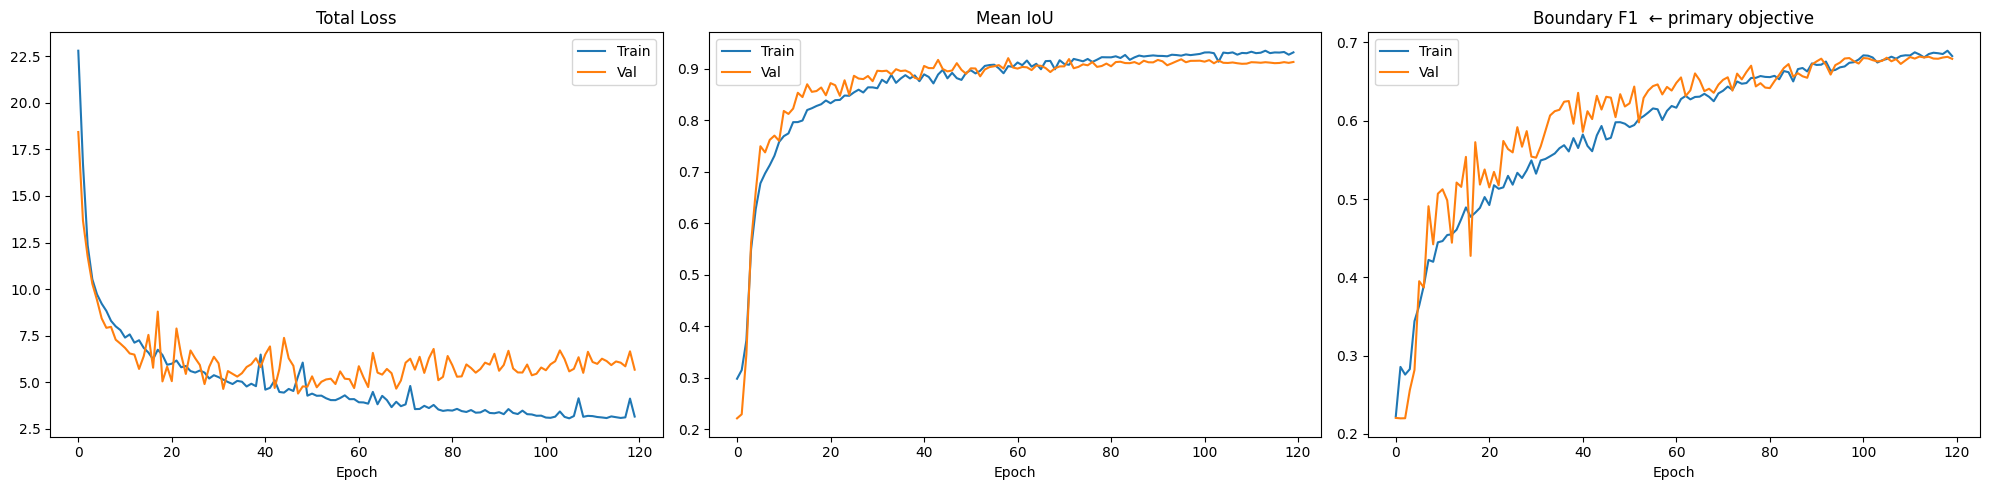

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Total Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['train_iou'], label='Train')
axes[1].plot(history['val_iou'],   label='Val')
axes[1].set_title('Mean IoU'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history['train_bf1'], label='Train')
axes[2].plot(history['val_bf1'],   label='Val')
axes[2].set_title('Boundary F1  ← primary objective')
axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

In [25]:
CHECKPOINT = os.path.join(OUTPUT_DIR, 'best.pt')  # saved on best BoundaryF1
IMG_PATH   = '/content/drive/MyDrive/AI-CropFieldSegmentation/Screenshot 2026-04-10 124127.png'

model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()

img_pil = Image.open(IMG_PATH).convert('RGB')
orig_w, orig_h = img_pil.size

preprocess = T.Compose([
    T.Resize([IMG_SIZE, IMG_SIZE]),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
input_tensor = preprocess(img_pil).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    out = model(input_tensor)

# ── Segmentation mask ─────────────────────────────────────────────────────────
pred_mask = out['seg'].argmax(dim=1).squeeze().cpu().numpy()

# ── Predicted boundary map ────────────────────────────────────────────────────
pred_bound = torch.sigmoid(out['bound']).squeeze().cpu().numpy()   # [0,1]

# ── Predicted distance map ────────────────────────────────────────────────────
pred_dist  = torch.sigmoid(out['dist']).squeeze().cpu().numpy()

# ── Use predicted boundary to cut the seg mask (key FracTAL advantage) ────────
# Pixels where the model is confident there's a boundary → set to background
BOUND_THRESH = 0.35  # lower → more boundary cuts; higher → fewer
hard_bound   = (pred_bound > BOUND_THRESH).astype(np.uint8)
pred_mask_cut = pred_mask.copy()
pred_mask_cut[hard_bound == 1] = 0   # erase seg prediction at boundaries

# Resize all outputs back to original resolution
def resize_map(arr, w, h, interp=Image.NEAREST):
    return np.array(Image.fromarray(arr.astype(np.uint8)).resize((w, h), interp))

pred_mask_full  = resize_map(pred_mask_cut, orig_w, orig_h)
pred_bound_full = resize_map((pred_bound*255).astype(np.uint8), orig_w, orig_h, Image.BILINEAR)
pred_dist_full  = resize_map((pred_dist *255).astype(np.uint8), orig_w, orig_h, Image.BILINEAR)

print(f'Unique predicted classes: {np.unique(pred_mask_full)}')
print(f'Boundary coverage: {hard_bound.mean()*100:.1f}% of pixels')
print(f'Crop-field pixels: {(pred_mask_full>0).sum():,} ({100*(pred_mask_full>0).mean():.1f}%)')


Unique predicted classes: [0 1]
Boundary coverage: 37.0% of pixels
Crop-field pixels: 499,346 (61.3%)


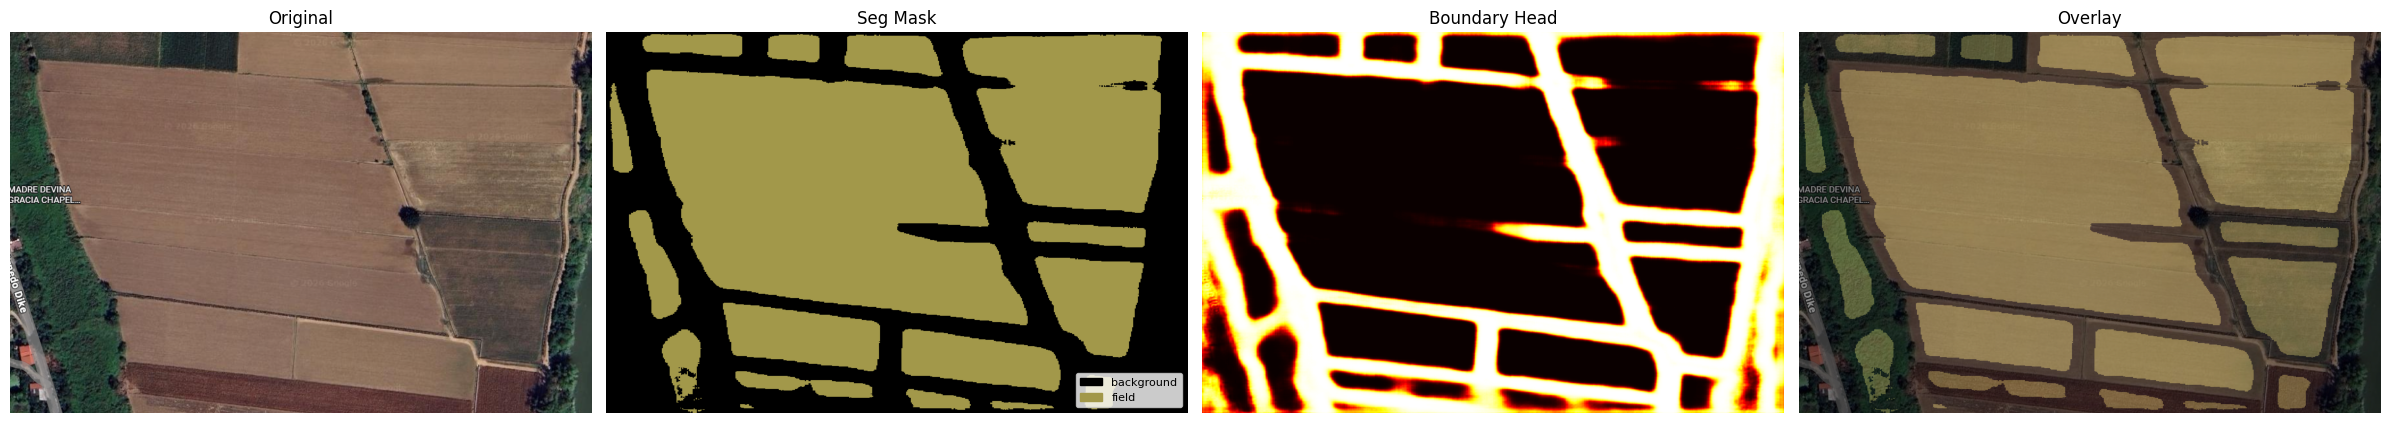

In [26]:
orig_arr = np.array(img_pil)

# Colour the seg mask
np.random.seed(42)
PALETTE = [(0,0,0)] + [tuple(np.random.randint(60,230,3).tolist()) for _ in range(NUM_CLASSES-1)]
color_mask = np.zeros((*pred_mask_full.shape,3), dtype=np.uint8)
for cls_id, rgb in enumerate(PALETTE):
    color_mask[pred_mask_full==cls_id] = rgb

overlay = (0.55*orig_arr + 0.45*color_mask).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes[0].imshow(orig_arr);        axes[0].set_title('Original');          axes[0].axis('off')
axes[1].imshow(color_mask);      axes[1].set_title('Seg Mask');          axes[1].axis('off')
axes[2].imshow(pred_bound_full, cmap='hot'); axes[2].set_title('Boundary Head'); axes[2].axis('off')
axes[3].imshow(overlay);         axes[3].set_title('Overlay');           axes[3].axis('off')

cat_names = ['background'] + [c['name'] for c in sorted(
    train_ds.coco.loadCats(train_ds.coco.getCatIds()), key=lambda x: x['id'])]
legend = [mpatches.Patch(color=np.array(PALETTE[i])/255, label=cat_names[i])
          for i in range(NUM_CLASSES)]
axes[1].legend(handles=legend, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'prediction_4panel.png'), dpi=150, bbox_inches='tight')
plt.show()
